# Notebook for Evaluation of Training

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from Trainer import *
from mesh import *
from baseline import *
from metrics import *
#from main import *
import numpy as np
import matplotlib.pyplot as plt
import os

e:\VSCodium\OML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Random vs. Haar init layer convergence sweep 

In [ ]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep=["random", "haar"] #all sweeps
sweep_label="init. type"

for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s:.3f}.json"))
    test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

## Learning rate

In [46]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep=[0.01, 0.03, 0.1, 0.3, 0.8,0.9,1.0,1.1,1.3,1.5,1.7,2.2,2.5,2.7,3,4,5.0,10.0,50.0] #all sweeps
sweep=[0.01, 0.03, 0.1, 0.3, 0.8,1.0,1.3,1.7,2.5,3,4,5.0,10.0,50.0] #relevant sweeps

sweep_label="learning_rate"
for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s:.3f}.json"))
    test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
learning_rate=0.01  epochs= 35 loss=0.36199  train acc=0.9550  test acc=0.9600  308s
learning_rate=0.03  epochs= 35 loss=0.22018  train acc=0.9600  test acc=0.9700  306s
learning_rate=0.1  epochs= 35 loss=0.19508  train acc=0.9656  test acc=0.9700  305s
learning_rate=0.3  epochs= 26 loss=0.19363  train acc=0.9650  test acc=0.9750  227s
learning_rate=0.8  epochs= 16 loss=0.19447  train acc=0.9675  test acc=0.9700  317s
learning_rate=1.0  epochs= 16 loss=0.19505  train acc=0.9681  test acc=0.9700  207s
learning_rate=1.3  epochs= 16 loss=0.19596  train acc=0.9681  test acc=0.9700  144s
learning_rate=1.7  epochs= 16 loss=0.19744  train acc=0.9688  test acc=0.9700  142s
learning_rate=2.5  epochs= 31 loss=0.20066  train acc=0.9681  test acc=0.9775  272s
learning_rate=3  epochs= 35 loss=0.20292  train acc=0.9594  test acc=0.9700  318s
learning_rate=4  epochs= 13 loss=0.69056  train acc=0.93

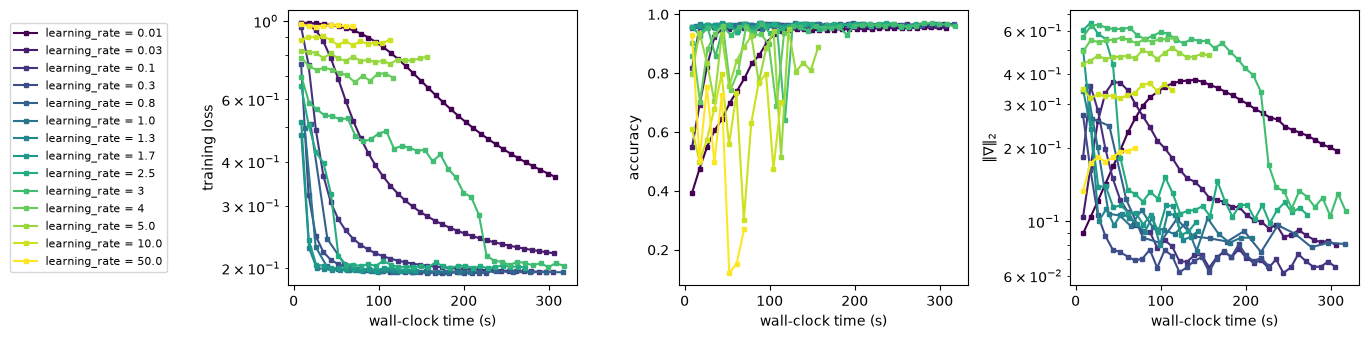

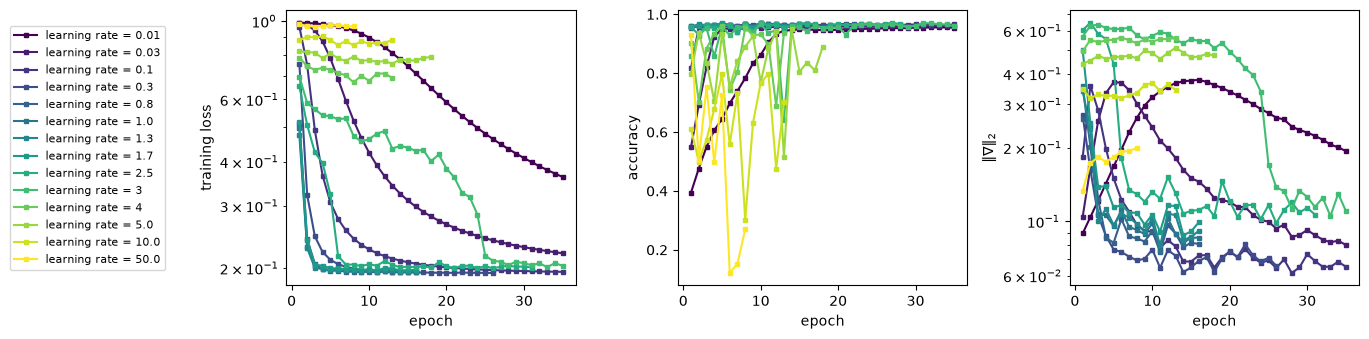

In [47]:
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label="learning_rate" ,keys=("loss", "acc", "grad_norm"), x_axis="time")
plt.savefig(f"results/{sweep_label}/plot_training_time.png",
            dpi=600, bbox_inches='tight')
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label="learning rate" ,keys=("loss", "acc", "grad_norm"), x_axis="epoch")
plt.savefig(f"results/{sweep_label}/plot_training_epoch.png",
            dpi=600, bbox_inches='tight')


## Smaller Batchsizes

In [43]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep=[0.03,1.0,1.3,1.7,5,10] #all sweeps

sweep_label="learning_rate_smaller_batchsize"
for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s:.3f}.json"))
    test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
learning_rate_smaller_batchsize=0.03  epochs= 26 loss=0.19383  train acc=0.9675  test acc=0.9775  1934s
learning_rate_smaller_batchsize=1.0  epochs= 32 loss=0.20578  train acc=0.9694  test acc=0.9750  2392s
learning_rate_smaller_batchsize=1.3  epochs= 28 loss=0.21209  train acc=0.9581  test acc=0.9675  2129s
learning_rate_smaller_batchsize=1.7  epochs= 21 loss=0.22124  train acc=0.9587  test acc=0.9525  1576s
learning_rate_smaller_batchsize=5  epochs=  7 loss=0.86037  train acc=0.9494  test acc=0.8425  521s
learning_rate_smaller_batchsize=10  epochs=  6 loss=0.90766  train acc=0.5150  test acc=0.8000  448s


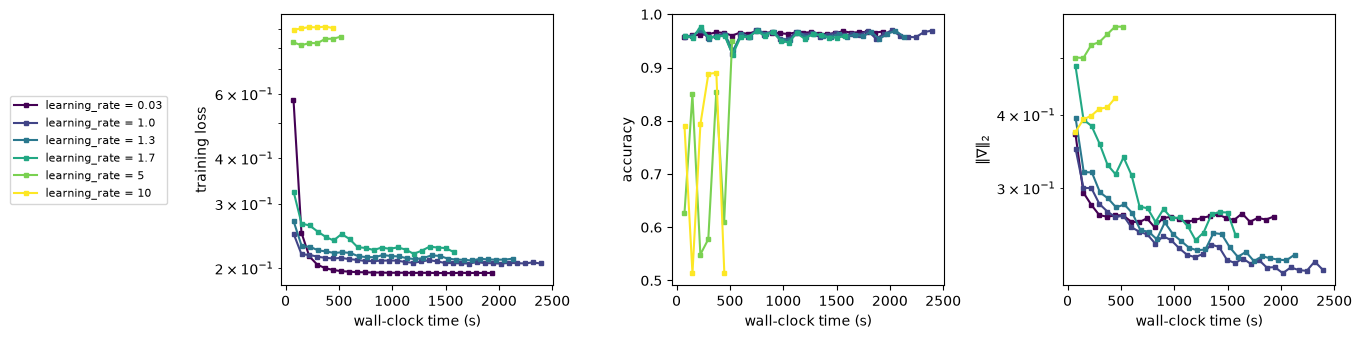

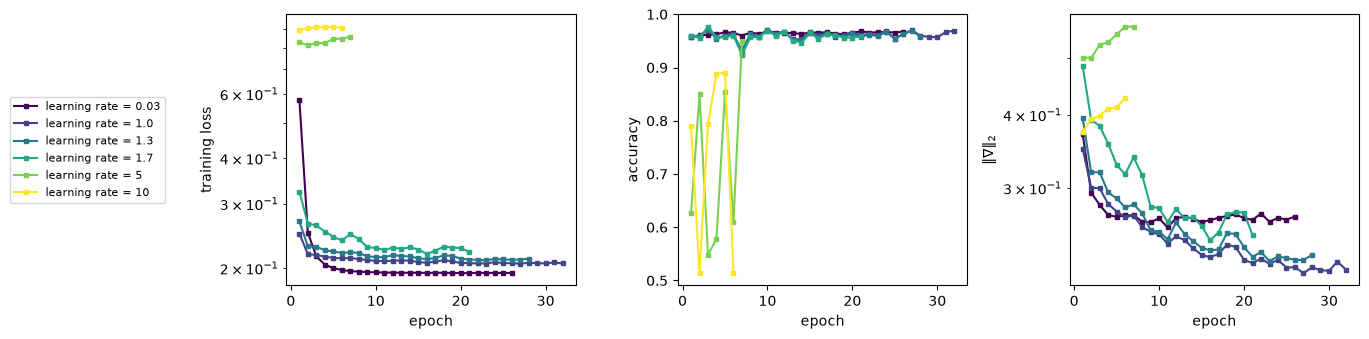

In [44]:
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label="learning_rate" ,keys=("loss", "acc", "grad_norm"), x_axis="time")
plt.savefig(f"results/{sweep_label}/plot_training_time.png",
            dpi=600, bbox_inches='tight')
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label="learning rate" ,keys=("loss", "acc", "grad_norm"), x_axis="epoch")
plt.savefig(f"results/{sweep_label}/plot_training_epoch.png",
            dpi=600, bbox_inches='tight')


## Bigger batchsize

In [48]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep=[0.03,1.0,1.3,1.7,5,10] #all sweeps

sweep_label="learning_rate_bigger_batchsize"
for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s:.3f}.json"))
    test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
learning_rate_bigger_batchsize=0.03  epochs= 35 loss=0.41603  train acc=0.9544  test acc=0.9600  154s
learning_rate_bigger_batchsize=1.0  epochs= 27 loss=0.19491  train acc=0.9700  test acc=0.9700  130s
learning_rate_bigger_batchsize=1.3  epochs= 27 loss=0.19559  train acc=0.9706  test acc=0.9675  126s
learning_rate_bigger_batchsize=1.7  epochs= 14 loss=0.19488  train acc=0.9619  test acc=0.9575  71s
learning_rate_bigger_batchsize=5  epochs= 13 loss=0.82526  train acc=0.9525  test acc=0.9000  63s
learning_rate_bigger_batchsize=10  epochs= 16 loss=0.90223  train acc=0.5044  test acc=0.5775  79s


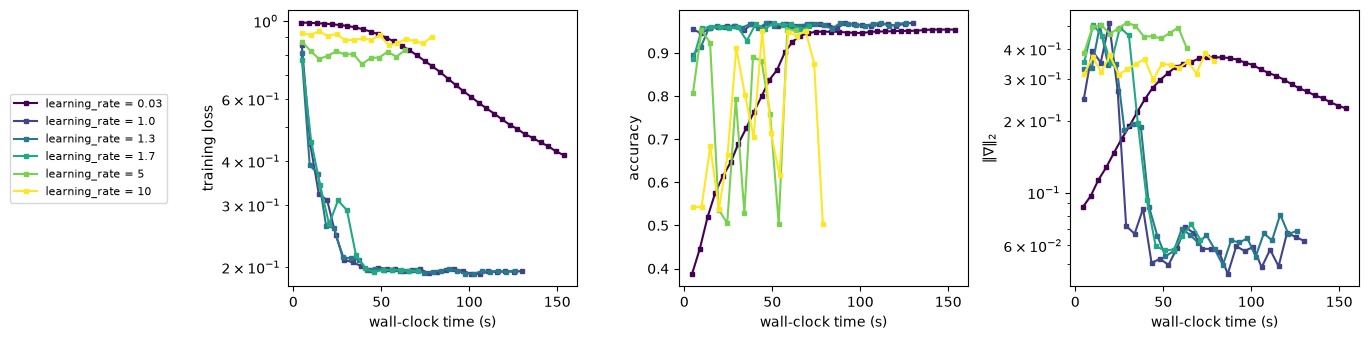

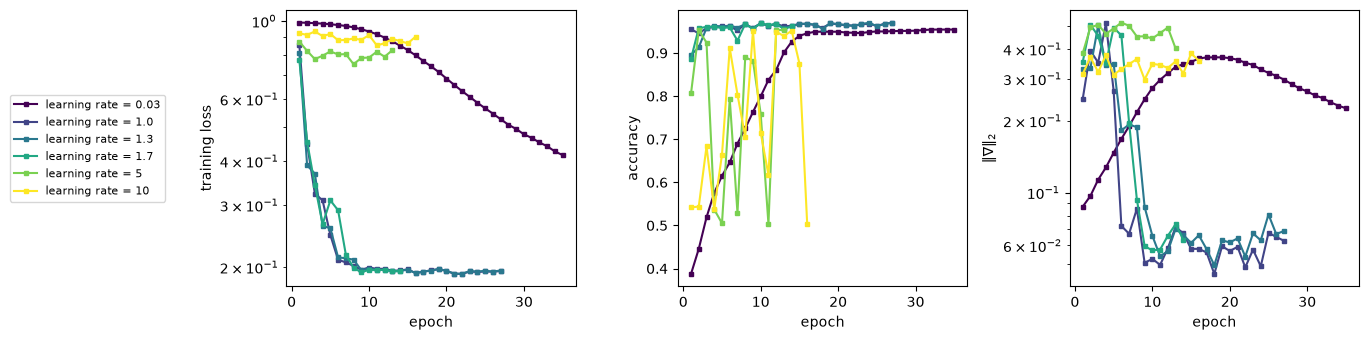

In [49]:
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label="learning_rate" ,keys=("loss", "acc", "grad_norm"), x_axis="time")
plt.savefig(f"results/{sweep_label}/plot_training_time.png",
            dpi=600, bbox_inches='tight')
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label="learning rate" ,keys=("loss", "acc", "grad_norm"), x_axis="epoch")
plt.savefig(f"results/{sweep_label}/plot_training_epoch.png",
            dpi=600, bbox_inches='tight')


## Sidelength m

In [41]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep = [6,8,10,14,18,22]
sweep_label = "m_sidelength"

for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s:.3f}.json"))
    #test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)
    

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
m_sidelength=6  epochs=  5 loss=0.22518  train acc=0.9225  test acc=0.9400  5s
m_sidelength=8  epochs=  5 loss=0.18545  train acc=0.9600  test acc=0.9625  15s
m_sidelength=10  epochs=  5 loss=0.19703  train acc=0.9681  test acc=0.9775  38s
m_sidelength=14  epochs=  5 loss=0.22042  train acc=0.9700  test acc=0.9800  161s
m_sidelength=18  epochs=  5 loss=0.25275  train acc=0.9663  test acc=0.9750  596s
m_sidelength=22  epochs=  5 loss=0.24848  train acc=0.9644  test acc=0.9750  1416s


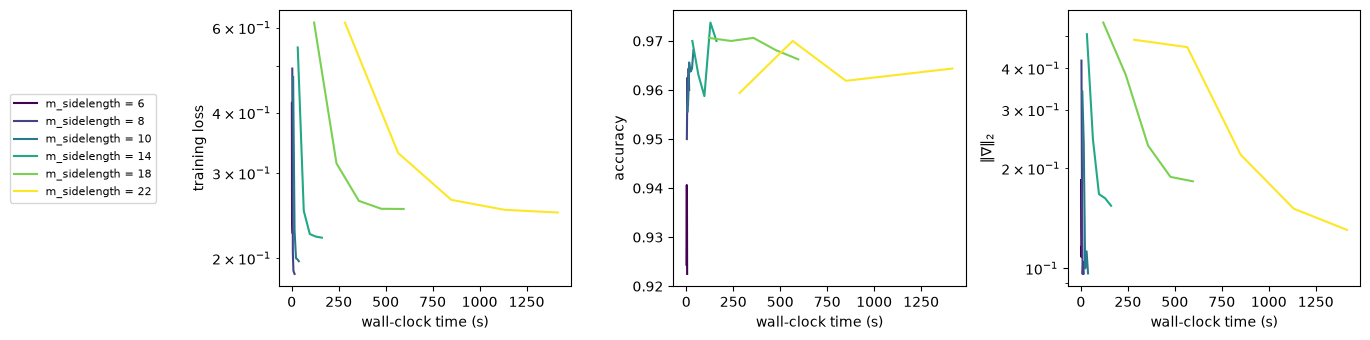

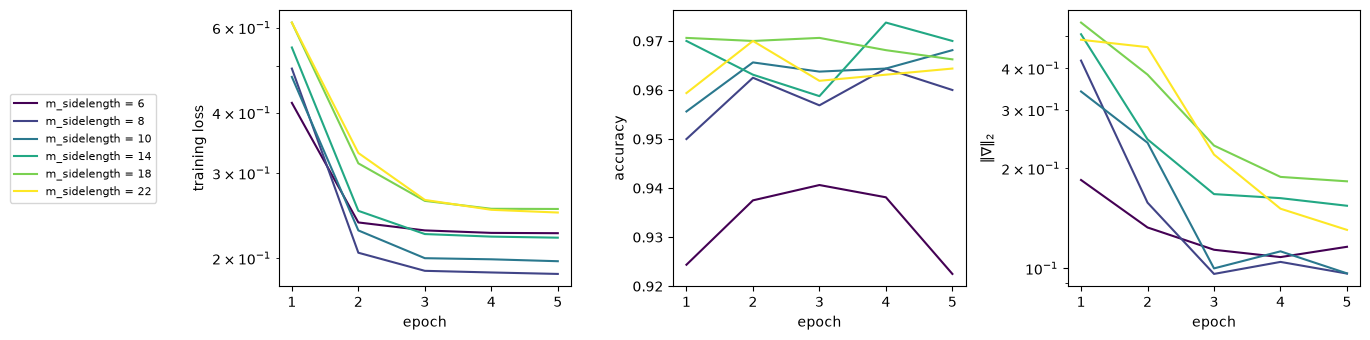

In [42]:
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label=sweep_label ,keys=("loss", "acc", "grad_norm"), x_axis="time")
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label=sweep_label ,keys=("loss", "acc", "grad_norm"), x_axis="epoch")
